# ==============================================================================
# Phase 0 : Configuration et Chargement des Données
# ==============================================================================

* Objectif : Importer toutes les bibliothèques nécessaires pour le prétraitement, la modélisation, l'évaluation et l'explicabilité. Charger le dataset et effectuer une vérification initiale.
Bibliothèques clés :
- Pandas, Numpy : Manipulation de données.
- Matplotlib, Seaborn : Visualisation.
- NLTK : Prétraitement de texte (stopwords, stemming/lemmatisation).
- Scikit-learn : Outils ML essentiels (split, vectorisation, modèles, métriques, pipelines, transformation de colonnes, validation croisée, recherche d'hyperparamètres).
- XGBoost : Modèle de gradient boosting performant.
- joblib : Sauvegarde et chargement des modèles/pipelines.
- shap : Bibliothèque pour l'explicabilité des modèles (optionnelle mais recommandée).
- Configuration : SEED est défini pour assurer la reproductibilité des étapes aléatoires (comme le train/test split).
- Chargement : Le fichier CSV est chargé. Des vérifications de base (head, info) sont effectuées. Une gestion d'erreur simple est ajoutée pour le cas où le fichier ne serait pas trouvé.

In [2]:
#cd "C:\Users\donfa\OneDrive\Desktop\INFO DESCISIONELLE\PROJET INFO DES"

C:\Users\donfa\OneDrive\Desktop\INFO DESCISIONELLE\PROJET INFO DES


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib # Pour sauvegarder/charger les modèles
import warnings

# NLTK pour le prétraitement
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer # Alternative: souvent mieux que PorterStemmer
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet') # Si utilisation de WordNetLemmatizer

# Scikit-learn : Préparation, Modèles, Métriques, Pipelines
from sklearn.model_selection import train_test_split, learning_curve, StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer
)

# Explicabilité
try:
    import shap
    shap.initjs() # Initialisation pour les plots SHAP dans les notebooks
    SHAP_AVAILABLE = True
except ImportError:
    print("SHAP n'est pas installé. L'étape d'explicabilité sera sautée.")
    print("Pour l'installer : pip install shap")
    SHAP_AVAILABLE = False

# Configuration
pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore', category=UserWarning) # Ignore certains warnings sklearn/nltk
sns.set(style="whitegrid")
SEED = 42 # Pour la reproductibilité

# Chargement des données
try:
    df = pd.read_csv('Data/sentiment_analysis.csv')
    print("Dataset chargé avec succès.")
    print(f"Dimensions initiales : {df.shape}")
except FileNotFoundError:
    print("Erreur : Fichier CSV non trouvé. Vérifiez le chemin d'accès.")
    # Possibilité de stopper l'exécution ou d'utiliser un chemin alternatif
    exit() # Ou raise Exception("Fichier non trouvé")

# Afficher un aperçu
print("\nAperçu des données :")
display(df.head())
print("\nInformations sur les colonnes :")
df.info()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\donfa\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\donfa\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\donfa\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Dataset chargé avec succès.
Dimensions initiales : (499, 7)

Aperçu des données :


,Year,Month,Day,Time of Tweet,text,sentiment,Platform
0,2018,8,18,morning,What a great day!!! Looks like dream.,positive,Twitter
1,2018,8,18,noon,"I feel sorry, I miss you here in the sea beach",positive,Facebook
2,2017,8,18,night,Don't angry me,negative,Facebook
3,2022,6,8,morning,We attend in the class just for listening teac...,negative,Facebook
4,2022,6,8,noon,"Those who want to go, let them go",negative,Instagram



Informations sur les colonnes :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 499 entries, 0 to 498
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Year           499 non-null    int64 
 1   Month          499 non-null    int64 
 2   Day            499 non-null    int64 
 3   Time of Tweet  499 non-null    object
 4   text           499 non-null    object
 5   sentiment      499 non-null    object
 6   Platform       499 non-null    object
dtypes: int64(3), object(4)
memory usage: 27.4+ KB


In [32]:
from xgboost import XGBClassifier


# ==============================================================================
# Phase 1 : Prétraitement et Préparation des Données
# ==============================================================================

* Objectif : Préparer les données pour l'entraînement : nettoyer le texte, encoder la variable cible, définir les ensembles de features et la cible, et séparer les données en ensembles d'entraînement et de test.
- Prétraitement Texte : La fonction preprocess_text_stemming (inspirée du Code 1) est utilisée pour nettoyer et normaliser le texte (minuscules, suppression caractères non alpha, suppression stopwords, stemming). Une colonne cleaned_text est créée. Note : La lemmatisation pourrait être une alternative plus qualitative.
- Encodage Cible : La colonne sentiment est transformée en sentiment_encoded avec le mapping {'neutral': 0, 'positive': 1, 'negative': 2}. C'est un format standard pour la classification multi-classe dans Scikit-learn. La distribution est vérifiée.
- Features & Cible : X contient toutes les colonnes sauf la cible (originale et encodée). y contient la cible encodée.
- Train/Test Split : Les données sont divisées en 80% pour l'entraînement (X_train, y_train) et 20% pour le test (X_test, y_test). stratify=y assure que la proportion de chaque sentiment est préservée dans les deux ensembles, ce qui est crucial pour une évaluation fiable, surtout avec un léger déséquilibre des classes. Les tailles et distributions sont vérifiées.
- Définition Colonnes : Les noms des colonnes à utiliser pour le texte (text_feature) et les métadonnées (metadata_features) sont définis pour faciliter leur utilisation ultérieure.

### mais avant comme vu pendant l'analyse exploratoire les noms des plateformes et les colones nulles posen des soucis 

In [3]:
df.drop_duplicates(inplace=True)
print("Doublons supprimés.")
df.reset_index(drop=True, inplace=True) # Réinitialiser l'index après suppression
df['Platform'] = df['Platform'].str.strip()
print("Soucis de noms de plateforme OK")


Doublons supprimés.
Soucis de noms de plateforme OK


### 1.1 Nettoyage du texte (Fonction de stemming comme dans Code 1)


In [6]:

ps = PorterStemmer()
# lemmatizer = WordNetLemmatizer() # Alternative
stop_words = set(stopwords.words('english'))

def preprocess_text_stemming(text):
    text = str(text).lower() # Minuscule
    text = re.sub(r'[^a-z\s]', '', text) # Garde seulement lettres et espaces
    tokens = text.split() # Tokenisation simple
    # Stemming et suppression des stopwords
    stemmed_tokens = [ps.stem(word) for word in tokens if word not in stop_words and len(word) > 1]
    # Rejoint les mots
    return " ".join(stemmed_tokens)

# Appliquer le prétraitement
df['cleaned_text'] = df['text'].apply(preprocess_text_stemming)
print("\nComparaison Texte Original vs Nettoyé :")
display(df[['text', 'cleaned_text']].head())



Comparaison Texte Original vs Nettoyé :


,text,cleaned_text
0,What a great day!!! Looks like dream.,great day look like dream
1,"I feel sorry, I miss you here in the sea beach",feel sorri miss sea beach
2,Don't angry me,dont angri
3,We attend in the class just for listening teac...,attend class listen teacher read slide nonsenc
4,"Those who want to go, let them go",want go let go


### 1.2 Encodage de la variable cible ('sentiment')

In [7]:

# On va utiliser 0: neutral, 1: positive, 2: negative (comme dans Code 1)
# La fonction finale de prédiction fera le mapping vers 0, 1, -1 si besoin.
sentiment_map = {'neutral': 0, 'positive': 1, 'negative': 2}
df['sentiment_encoded'] = df['sentiment'].map(sentiment_map)

# Vérifier l'encodage et la distribution
print("\nDistribution des sentiments encodés :")
print(df['sentiment_encoded'].value_counts())
print(f"Valeurs manquantes dans sentiment_encoded : {df['sentiment_encoded'].isnull().sum()}")

# Définition des Features (X) et de la Cible (y)
X = df.drop(['sentiment', 'sentiment_encoded'], axis=1) # Features potentielles
y = df['sentiment_encoded'] # Cible encodée



Distribution des sentiments encodés :
sentiment_encoded
0    153
1    132
2    109
Name: count, dtype: int64
Valeurs manquantes dans sentiment_encoded : 0


### 1.3 Séparation Entraînement / Test (Stratifiée)

In [26]:

# On sépare tout le DataFrame X pour garder les métadonnées disponibles
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.35, # 20% pour le test (comme Code 1)
    random_state=SEED,
    stratify=y # Très important pour garder les proportions de sentiments
)

print(f"\nTaille du jeu d'entraînement : {X_train.shape}, {y_train.shape}")
print(f"Taille du jeu de test : {X_test.shape}, {y_test.shape}")
print("\nDistribution des sentiments dans y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribution des sentiments dans y_test:")
print(y_test.value_counts(normalize=True)) # Doit être similaire à y_train

# Définir les colonnes pour les différents types de modèles
text_feature = 'cleaned_text'
metadata_features = ['Platform', 'Time of Tweet'] # Colonnes identifiées comme pertinentes


Taille du jeu d'entraînement : (256, 7), (256,)
Taille du jeu de test : (138, 7), (138,)

Distribution des sentiments dans y_train:
sentiment_encoded
0    0.386719
1    0.335938
2    0.277344
Name: proportion, dtype: float64

Distribution des sentiments dans y_test:
sentiment_encoded
0    0.391304
1    0.333333
2    0.275362
Name: proportion, dtype: float64


# ==============================================================================
# Phase 2 : Entraînement et Évaluation - Modèles "Text Only"
# ==============================================================================

* Objectif : Entraîner et évaluer plusieurs modèles de classification en utilisant uniquement les données textuelles (cleaned_text). Comparer leurs performances pour identifier les candidats potentiels.
* Pipeline text_pipeline : Un Pipeline Scikit-learn est défini. Il enchaîne :
- TfidfVectorizer : Transforme le texte en vecteurs TF-IDF. max_features=5000 limite la taille du vocabulaire pour éviter une dimensionnalité trop élevée. ngram_range=(1, 2) inclut les mots seuls (unigrammes) et les paires de mots (bigrammes), ce qui capture un peu plus de contexte que les unigrammes seuls (comme dans le Code 2 qui utilisait TF-IDF avec unigrammes par défaut). C'est un compromis par rapport au ngram_range=(1, 5) du Code 1 qui utilisait CountVectorizer et pouvait générer beaucoup trop de features.
- classifier : Un espace réservé qui sera remplacé par chaque modèle testé.
* Modèles Testés : Une sélection de classifieurs classiques et performants :
- LogisticRegression : Bon baseline, souvent efficace pour le texte.
- MultinomialNB : Classifieur Naive Bayes adapté aux données de comptage (comme BoW ou TF-IDF). Rapide.
- SVC (Linear) : Support Vector Machine avec noyau linéaire, souvent performant sur des données de haute dimension comme le texte vectorisé.
- XGBoost : Algorithme de Gradient Boosting puissant, peut capturer des interactions complexes. Les paramètres sont définis (moins d'arbres que dans le Code 2 pour un premier test rapide).
* Boucle d'Entraînement/Évaluation :
Chaque modèle est inséré dans le pipeline.
Le pipeline complet est entraîné sur les textes de X_train.
Les prédictions sont faites sur les textes de X_test.
- L'évaluation est effectuée en utilisant :
- accuracy_score : Pourcentage de prédictions correctes.
- f1_score(average='weighted') : Moyenne pondérée du F1-score par classe. C'est une métrique robuste, surtout en cas de léger déséquilibre des classes, car elle équilibre précision et rappel.
- classification_report : Donne la précision, le rappel, le F1-score pour chaque classe. Très utile pour voir si le modèle performe bien sur toutes les classes ou s'il a des difficultés avec certaines (par ex. la classe 'negative' qui a le moins d'exemples).
- confusion_matrix : Tableau montrant les prédictions correctes et incorrectes pour chaque classe (vrai vs prédit). Permet d'identifier les types d'erreurs les plus courants (ex: confusion entre 'neutral' et 'negative').
Les résultats et le pipeline entraîné sont stockés dans results_text_only.
Une heatmap de la matrice de confusion est affichée pour chaque modèle.
- Comparaison : Les scores (Accuracy, F1 Weighted) sont rassemblés dans un DataFrame et visualisés dans un graphique à barres pour comparer facilement les performances globales des modèles testés.

### 2.1 Définition du Pipeline "Text Only"

In [33]:
print("\n" + "="*50)
print(" Phase 2 : Modèles basés uniquement sur le Texte ")
print("="*50 + "\n")

# Le pipeline inclura la vectorisation TF-IDF et le classifieur
text_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))), # TF-IDF avec bigrammes, limite features
    ('classifier', None) # Placeholder pour le modèle
])

# Modèles à tester
models_to_test = {
    "Logistic Regression": LogisticRegression(random_state=SEED, max_iter=1000, C=1.0, solver='liblinear'),
    "Multinomial NB": MultinomialNB(alpha=1.0),
    "SVC (Linear)": SVC(kernel='linear', probability=True, random_state=SEED, C=1.0), # probability=True pour SHAP si besoin
    "XGBoost": XGBClassifier(objective='multi:softmax', num_class=3, use_label_encoder=False,
                             eval_metric='mlogloss', random_state=SEED, n_estimators=300, # Moins d'estimateurs que Code 2 pour commencer
                             learning_rate=0.1, max_depth=3, subsample=0.7, colsample_bytree=0.7)
}



 Phase 2 : Modèles basés uniquement sur le Texte 



### 2.2 Boucle d'entraînement et d'évaluation


--- Entraînement et Évaluation : Logistic Regression ---
Accuracy: 0.4928
F1-Score (Weighted): 0.4532
Classification Report:
               precision    recall  f1-score   support

 neutral (0)       0.46      0.76      0.57        54
positive (1)       0.55      0.48      0.51        46
negative (2)       0.62      0.13      0.22        38

    accuracy                           0.49       138
   macro avg       0.54      0.46      0.43       138
weighted avg       0.53      0.49      0.45       138

Confusion Matrix:
 [[41 11  2]
 [23 22  1]
 [26  7  5]]


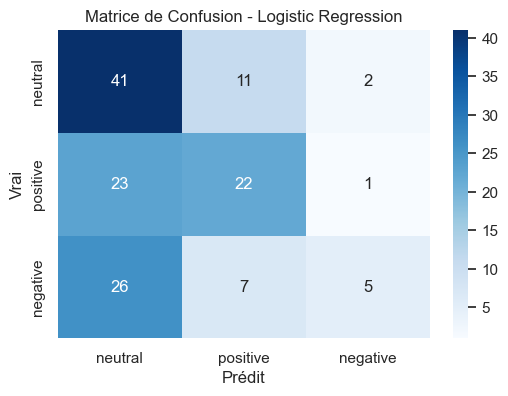


--- Entraînement et Évaluation : Multinomial NB ---
Accuracy: 0.4928
F1-Score (Weighted): 0.4666
Classification Report:
               precision    recall  f1-score   support

 neutral (0)       0.46      0.69      0.55        54
positive (1)       0.50      0.52      0.51        46
negative (2)       0.70      0.18      0.29        38

    accuracy                           0.49       138
   macro avg       0.55      0.46      0.45       138
weighted avg       0.54      0.49      0.47       138

Confusion Matrix:
 [[37 15  2]
 [21 24  1]
 [22  9  7]]


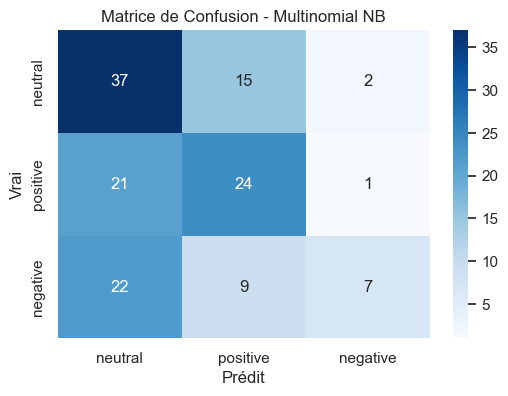


--- Entraînement et Évaluation : SVC (Linear) ---
Accuracy: 0.4710
F1-Score (Weighted): 0.4633
Classification Report:
               precision    recall  f1-score   support

 neutral (0)       0.46      0.57      0.51        54
positive (1)       0.50      0.50      0.50        46
negative (2)       0.44      0.29      0.35        38

    accuracy                           0.47       138
   macro avg       0.47      0.45      0.45       138
weighted avg       0.47      0.47      0.46       138

Confusion Matrix:
 [[31 14  9]
 [18 23  5]
 [18  9 11]]


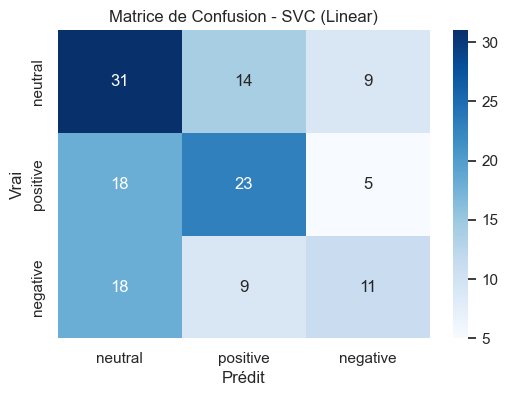


--- Entraînement et Évaluation : XGBoost ---
Accuracy: 0.4348
F1-Score (Weighted): 0.4058
Classification Report:
               precision    recall  f1-score   support

 neutral (0)       0.46      0.67      0.55        54
positive (1)       0.44      0.41      0.43        46
negative (2)       0.29      0.13      0.18        38

    accuracy                           0.43       138
   macro avg       0.40      0.40      0.38       138
weighted avg       0.41      0.43      0.41       138

Confusion Matrix:
 [[36 12  6]
 [21 19  6]
 [21 12  5]]


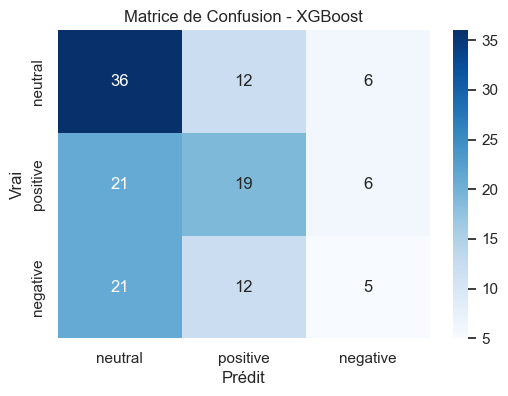

In [34]:
results_text_only = {}

for model_name, model in models_to_test.items():
    print(f"\n--- Entraînement et Évaluation : {model_name} ---")

    # Mettre à jour le classifieur dans le pipeline
    current_pipeline = Pipeline(steps=[
        ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))), # Re-instancier pour être sûr
        ('classifier', model)
    ])

    # Entraînement sur X_train[text_feature]
    current_pipeline.fit(X_train[text_feature], y_train)

    # Prédictions sur X_test[text_feature]
    y_pred = current_pipeline.predict(X_test[text_feature])

    # Évaluation
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted') # Weighted F1 est bon pour déséquilibre léger
    report = classification_report(y_test, y_pred, target_names=['neutral (0)', 'positive (1)', 'negative (2)'])
    cm = confusion_matrix(y_test, y_pred)

    results_text_only[model_name] = {
        'model': current_pipeline, # Sauvegarde du pipeline entraîné
        'accuracy': accuracy,
        'f1_weighted': f1,
        'report': report,
        'confusion_matrix': cm
    }

    # Affichage des résultats
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score (Weighted): {f1:.4f}")
    print("Classification Report:\n", report)
    print("Confusion Matrix:\n", cm)

    # Visualisation de la Matrice de Confusion
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['neutral', 'positive', 'negative'],
                yticklabels=['neutral', 'positive', 'negative'])
    plt.title(f'Matrice de Confusion - {model_name}')
    plt.xlabel('Prédit')
    plt.ylabel('Vrai')
    plt.show()


### Le SVC (super vector machine) avec noyau lineaire semble etre le model le plus precis en attendant XGBoost. les resultats sont les suivants :

--- Entraînement et Évaluation : Logistic Regression ---
Accuracy: 0.4177
F1-Score (Weighted): 0.3783
Classification Report:
               precision    recall  f1-score   support

 neutral (0)       0.41      0.65      0.50        31
positive (1)       0.42      0.42      0.42        26
negative (2)       0.50      0.09      0.15        22

    accuracy                           0.42        79
   macro avg       0.44      0.39      0.36        79
weighted avg       0.44      0.42      0.38        79

Confusion Matrix:
 [[20  9  2]
 [15 11  0]
 [14  6  2]]
 

--- Entraînement et Évaluation : Multinomial NB ---
Accuracy: 0.4430
F1-Score (Weighted): 0.3877
Classification Report:
               precision    recall  f1-score   support

 neutral (0)       0.43      0.68      0.53        31
positive (1)       0.46      0.50      0.48        26
negative (2)       0.50      0.05      0.08        22

    accuracy                           0.44        79
   macro avg       0.46      0.41      0.36        79
weighted avg       0.46      0.44      0.39        79

Confusion Matrix:
 [[21  9  1]
 [13 13  0]
 [15  6  1]]
 

--- Entraînement et Évaluation : SVC (Linear) ---
Accuracy: 0.4430
F1-Score (Weighted): 0.4308
Classification Report:
               precision    recall  f1-score   support

 neutral (0)       0.42      0.55      0.48        31
positive (1)       0.46      0.50      0.48        26
negative (2)       0.45      0.23      0.30        22

    accuracy                           0.44        79
   macro avg       0.45      0.43      0.42        79
weighted avg       0.45      0.44      0.43        79

Confusion Matrix:
 [[17 10  4]
 [11 13  2]
 [12  5  5]]

### 2.3 Comparaison des modèles "Text Only"


--- Comparaison des Modèles (Text Only) ---
                     Accuracy  F1 Weighted
Multinomial NB       0.492754     0.466620
SVC (Linear)         0.471014     0.463328
Logistic Regression  0.492754     0.453230
XGBoost              0.434783     0.405827


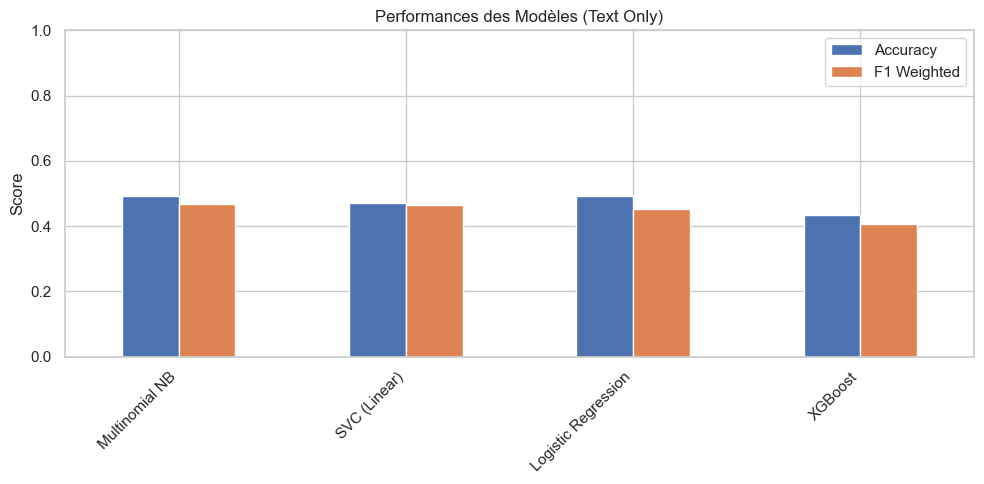

In [35]:
print("\n--- Comparaison des Modèles (Text Only) ---")
results_df_text = pd.DataFrame({
    model: {'Accuracy': res['accuracy'], 'F1 Weighted': res['f1_weighted']}
    for model, res in results_text_only.items()
}).T.sort_values(by='F1 Weighted', ascending=False)

print(results_df_text)
results_df_text.plot(kind='bar', figsize=(10, 5), title='Performances des Modèles (Text Only)')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### nous partirons donc sur le SV linear

# ==============================================================================
# Phase 3 : Analyse de l'Overfitting (Courbes d'Apprentissage)
# ==============================================================================

### Objectif : Diagnostiquer si les modèles souffrent de sur apprentissage (overfitting) ou de sous-apprentissage (underfitting) en analysant leur performance en fonction de la taille du jeu de données d'entraînement.
- Courbes d'Apprentissage (learning_curve) : Cette fonction de Scikit-learn entraîne le modèle sur des sous-ensembles croissants du jeu d'entraînement et évalue sa performance (ici, le F1-score pondéré) à la fois sur ces sous-ensembles (score d'entraînement) et sur un jeu de validation croisée (score de validation).
- Fonction plot_learning_curve : Une fonction utilitaire est définie pour générer et afficher les courbes. Elle utilise StratifiedKFold pour la validation croisée, ce qui est approprié pour la classification stratifiée. Le F1-score pondéré est utilisé comme métrique.
- Interprétation des Courbes :
- Surapprentissage (High Variance) : La courbe d'entraînement montre un score très élevé (proche de 1.0) qui reste élevé même avec plus de données, tandis que la courbe de validation stagne à un niveau nettement inférieur. Il y a un grand écart entre les deux courbes. Le modèle mémorise trop bien les données d'entraînement et ne généralise pas. Actions possibles : Réduire la complexité du modèle (régularisation plus forte, moins de features, moins de profondeur pour les arbres), obtenir plus de données.
- Sous-apprentissage (High Bias) : Les deux courbes (entraînement et validation) convergent vers un score relativement bas. Le modèle est trop simple pour capturer la structure des données. Actions possibles : Augmenter la complexité du modèle (moins de régularisation, plus de features, modèle plus puissant), améliorer les features.
- Idéal : Les deux courbes convergent vers un score élevé, avec un faible écart entre elles.
- Application : Les courbes sont tracées pour le(s) modèle(s) semblant les plus performants d'après la Phase 2 (ex: le meilleur selon le F1-score et potentiellement XGBoost s'il est différent). L'analyse de ces courbes donne des indications précieuses sur la fiabilité des scores obtenus et sur les pistes d'amélioration éventuelles. Attention : Avec un dataset aussi petit (seulement ~400 points d'entraînement), les courbes peuvent être bruitées et l'overfitting est un risque réel.


 Phase 3 : Analyse de l'Overfitting (Courbes d'Apprentissage) 



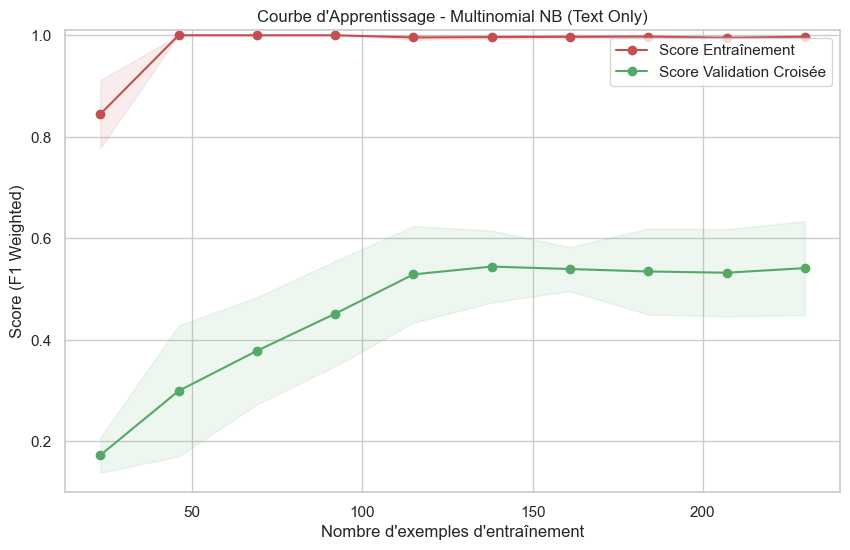

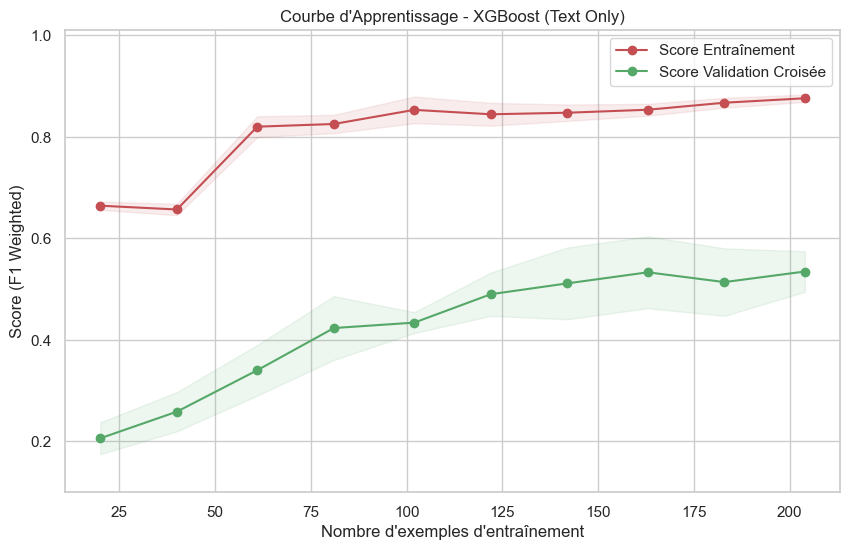

In [36]:
print("\n" + "="*50)
print(" Phase 3 : Analyse de l'Overfitting (Courbes d'Apprentissage) ")
print("="*50 + "\n")

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 10)):
    """Génère une courbe d'apprentissage simple pour un estimateur."""
    plt.figure(figsize=(10, 6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Nombre d'exemples d'entraînement")
    plt.ylabel("Score (F1 Weighted)") # On utilise F1 comme score

    # Utiliser StratifiedKFold pour la validation croisée (bon pour la classification)
    if cv is None:
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    # Utiliser F1-weighted comme métrique de scoring
    f1_scorer = make_scorer(f1_score, average='weighted')

    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes, scoring=f1_scorer)

    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)

    plt.grid(True)
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Score Entraînement")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Score Validation Croisée")

    plt.legend(loc="best")
    return plt

# Sélectionner les modèles les plus prometteurs pour l'analyse
# Par exemple, le meilleur modèle du classement précédent et peut-être XGBoost
best_model_name_text = results_df_text.index[0]
model_to_plot1 = results_text_only[best_model_name_text]['model']

# On doit utiliser le pipeline complet ici sur les données textuelles
plot_learning_curve(model_to_plot1, f"Courbe d'Apprentissage - {best_model_name_text} (Text Only)",
                    X_train[text_feature], y_train, ylim=(0.1, 1.01), cv=10)
plt.show()

# Si XGBoost est différent du meilleur, on le trace aussi
if "XGBoost" in results_text_only and best_model_name_text != "XGBoost":
     model_to_plot2 = results_text_only["XGBoost"]['model']
     plot_learning_curve(model_to_plot2, "Courbe d'Apprentissage - XGBoost (Text Only)",
                         X_train[text_feature], y_train, ylim=(0.1, 1.01), cv=5)
     plt.show()

### Il n'y a donc pas de surapprentissage ou presque car on voit que le nombre d'elements ideal pour un bon F1-score est d'environ 225 soit pres de 65% du dataset , 

# ==============================================================================
# Phase 4 : Entraînement et Évaluation - Modèles "Text + Metadata"
# ==============================================================================

### Objectif : Entraîner et évaluer des modèles en utilisant à la fois le texte et les métadonnées jugées pertinentes (Platform, Time of Tweet). Comparer leurs performances à celles des modèles "Text Only" pour déterminer si les métadonnées apportent une amélioration significative.
- ColumnTransformer : C'est l'outil clé pour appliquer différents prétraitements à différentes colonnes. Ici :
Le TfidfVectorizer (avec les mêmes paramètres que précédemment) est appliqué à la colonne cleaned_text.
Le OneHotEncoder est appliqué aux colonnes Platform et Time of Tweet. Le One-Hot Encoding transforme chaque catégorie en une nouvelle colonne binaire (0 ou 1), ce qui est une manière standard de traiter les features catégorielles pour la plupart des modèles. handle_unknown='ignore' est important pour que le modèle ne plante pas s'il rencontre une catégorie dans les données de test qui n'était pas présente dans l'entraînement.
- Pipeline full_pipeline : Ce pipeline intègre maintenant le ColumnTransformer comme première étape, suivi du classifieur.
- Modèles Testés : La sélection peut être ajustée. LogisticRegression et XGBoost sont généralement de bons candidats car ils gèrent bien les features hétérogènes (sparse TF-IDF + dense One-Hot).
- Entraînement/Évaluation : Le processus est similaire à la Phase 2, mais le pipeline complet est entraîné sur X_train (qui contient toutes les colonnes nécessaires) et évalué sur X_test. Le ColumnTransformer se charge de sélectionner et traiter les bonnes colonnes.
- Comparaisons :
Les performances des modèles "Text + Metadata" sont comparées entre eux.
Une comparaison globale est effectuée entre les meilleurs modèles "Text Only" et les meilleurs modèles "Text + Metadata" (basée sur le F1-score pondéré). Cela permet de répondre à la question : L'ajout des métadonnées améliore-t-il significativement la prédiction du sentiment dans ce cas ? La visualisation aide à voir clairement si un type de modèle surpasse l'autre.


### 4.1 Définition du Préprocesseur Combiné (ColumnTransformer)


In [38]:

print("\n" + "="*50)
print(" Phase 4 : Modèles basés sur Texte + Métadonnées ")
print("="*50 + "\n")

# Combine le traitement du texte et l'encodage des métadonnées

preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=5000, ngram_range=(1, 2)), text_feature),
        ('metadata', OneHotEncoder(handle_unknown='ignore'), metadata_features)
        # handle_unknown='ignore' : si une nouvelle catégorie apparaît dans le test,
        # elle sera encodée comme un vecteur de zéros.
    ],
    remainder='drop' # Ignore les autres colonnes non spécifiées
)

# 4.2 Définition du Pipeline "Text + Metadata"
full_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('classifier', None) # Placeholder
])



 Phase 4 : Modèles basés sur Texte + Métadonnées 



### 4.3 Modèles à tester (On peut reprendre les mêmes ou une sélection)

In [39]:

# Certains modèles comme Naive Bayes sont moins directs avec des features hétérogènes (sparse text + dense OHE)
# Logistic Regression et XGBoost gèrent bien cela. Essayons ceux-là.
models_to_test_full = {
    "Logistic Regression": LogisticRegression(random_state=SEED, max_iter=1000, C=1.0, solver='liblinear'),
    "XGBoost": XGBClassifier(objective='multi:softmax', num_class=3, use_label_encoder=False,
                             eval_metric='mlogloss', random_state=SEED, n_estimators=300,
                             learning_rate=0.1, max_depth=3, subsample=0.7, colsample_bytree=0.7),
    "Multinomial NB": MultinomialNB(alpha=1.0),
    "SVC (Linear)": SVC(kernel='linear', probability=True, random_state=SEED, C=1.0), 
    # On pourrait aussi tester SVC mais l'entraînement peut être plus long
}


### 4.4 Boucle d'entraînement et d'évaluation


--- Entraînement et Évaluation (Full) : Logistic Regression ---
Accuracy: 0.4348
F1-Score (Weighted): 0.4308
Classification Report:
               precision    recall  f1-score   support

 neutral (0)       0.43      0.52      0.47        54
positive (1)       0.43      0.43      0.43        46
negative (2)       0.46      0.32      0.38        38

    accuracy                           0.43       138
   macro avg       0.44      0.42      0.43       138
weighted avg       0.44      0.43      0.43       138

Confusion Matrix:
 [[28 16 10]
 [22 20  4]
 [15 11 12]]


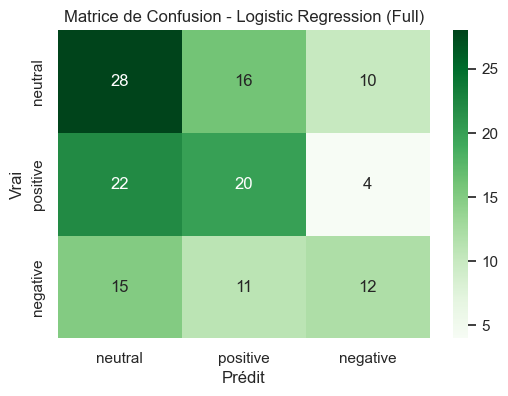


--- Entraînement et Évaluation (Full) : XGBoost ---
Accuracy: 0.4565
F1-Score (Weighted): 0.4497
Classification Report:
               precision    recall  f1-score   support

 neutral (0)       0.44      0.57      0.50        54
positive (1)       0.51      0.46      0.48        46
negative (2)       0.42      0.29      0.34        38

    accuracy                           0.46       138
   macro avg       0.46      0.44      0.44       138
weighted avg       0.46      0.46      0.45       138

Confusion Matrix:
 [[31 13 10]
 [20 21  5]
 [20  7 11]]


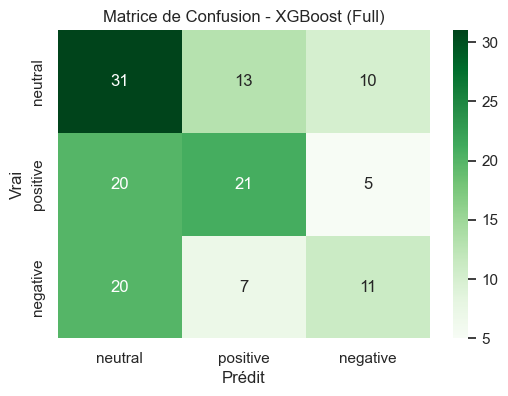


--- Entraînement et Évaluation (Full) : Multinomial NB ---
Accuracy: 0.4565
F1-Score (Weighted): 0.4055
Classification Report:
               precision    recall  f1-score   support

 neutral (0)       0.43      0.74      0.54        54
positive (1)       0.49      0.43      0.46        46
negative (2)       0.75      0.08      0.14        38

    accuracy                           0.46       138
   macro avg       0.56      0.42      0.38       138
weighted avg       0.54      0.46      0.41       138

Confusion Matrix:
 [[40 13  1]
 [26 20  0]
 [27  8  3]]


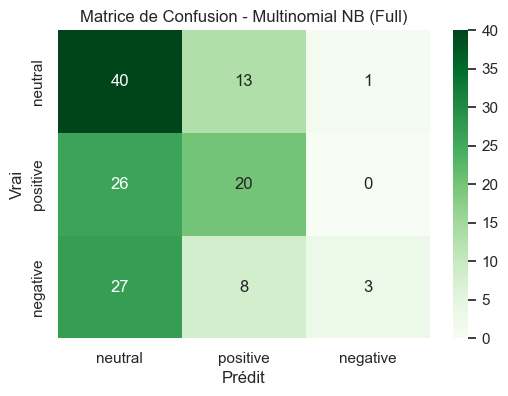


--- Entraînement et Évaluation (Full) : SVC (Linear) ---
Accuracy: 0.4565
F1-Score (Weighted): 0.4541
Classification Report:
               precision    recall  f1-score   support

 neutral (0)       0.42      0.48      0.45        54
positive (1)       0.50      0.52      0.51        46
negative (2)       0.46      0.34      0.39        38

    accuracy                           0.46       138
   macro avg       0.46      0.45      0.45       138
weighted avg       0.46      0.46      0.45       138

Confusion Matrix:
 [[26 16 12]
 [19 24  3]
 [17  8 13]]


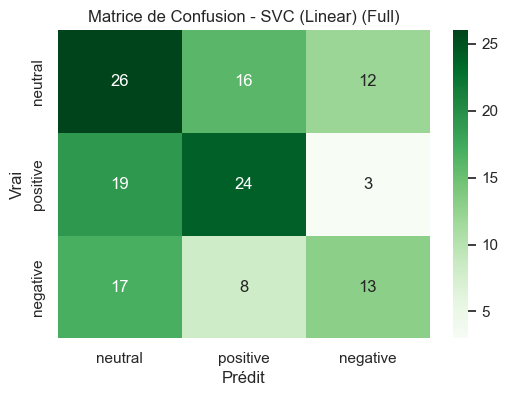

In [42]:

results_full = {}

for model_name, model in models_to_test_full.items():
    print(f"\n--- Entraînement et Évaluation (Full) : {model_name} ---")

    # Mettre à jour le classifieur dans le pipeline complet
    current_full_pipeline = Pipeline(steps=[
        ('preprocessing', preprocessor), # Utilise le ColumnTransformer
        ('classifier', model)
    ])

    # Entraînement sur X_train (qui contient texte et métadonnées)
    current_full_pipeline.fit(X_train, y_train) # Passe tout X_train, ColumnTransformer sélectionne les bonnes colonnes

    # Prédictions sur X_test
    y_pred_full = current_full_pipeline.predict(X_test)

    # Évaluation
    accuracy = accuracy_score(y_test, y_pred_full)
    f1 = f1_score(y_test, y_pred_full, average='weighted')
    report = classification_report(y_test, y_pred_full, target_names=['neutral (0)', 'positive (1)', 'negative (2)'])
    cm = confusion_matrix(y_test, y_pred_full)

    results_full[model_name] = {
        'model': current_full_pipeline, # Sauvegarde du pipeline entraîné
        'accuracy': accuracy,
        'f1_weighted': f1,
        'report': report,
        'confusion_matrix': cm
    }

    # Affichage des résultats
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score (Weighted): {f1:.4f}")
    print("Classification Report:\n", report)
    print("Confusion Matrix:\n", cm)

    # Visualisation de la Matrice de Confusion
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
                xticklabels=['neutral', 'positive', 'negative'],
                yticklabels=['neutral', 'positive', 'negative'])
    plt.title(f'Matrice de Confusion - {model_name} (Full)')
    plt.xlabel('Prédit')
    plt.ylabel('Vrai')
    plt.show()



### 4.5 Comparaison des modèles "Text + Metadata"


--- Comparaison des Modèles (Text + Metadata) ---
                     Accuracy  F1 Weighted
SVC (Linear)         0.456522     0.454101
XGBoost              0.456522     0.449662
Logistic Regression  0.434783     0.430773
Multinomial NB       0.456522     0.405549


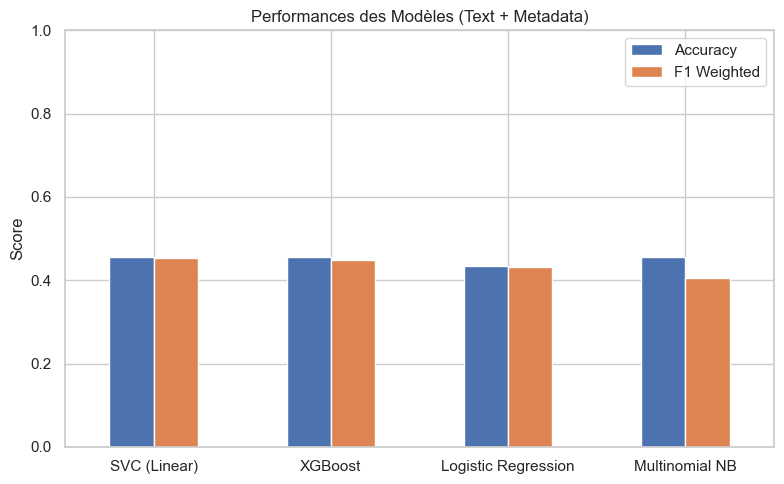

In [43]:

print("\n--- Comparaison des Modèles (Text + Metadata) ---")
results_df_full = pd.DataFrame({
    model: {'Accuracy': res['accuracy'], 'F1 Weighted': res['f1_weighted']}
    for model, res in results_full.items()
}).T.sort_values(by='F1 Weighted', ascending=False)

print(results_df_full)
results_df_full.plot(kind='bar', figsize=(8, 5), title='Performances des Modèles (Text + Metadata)')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()



### 4.6 Comparaison Globale : Text Only vs Text + Metadata


--- Comparaison Globale : Text Only vs Text + Metadata ---
                     Accuracy  F1 Weighted             Type
Multinomial NB       0.492754     0.466620        Text Only
SVC (Linear)         0.471014     0.463328        Text Only
SVC (Linear)         0.456522     0.454101  Text + Metadata
Logistic Regression  0.492754     0.453230        Text Only
XGBoost              0.456522     0.449662  Text + Metadata
Logistic Regression  0.434783     0.430773  Text + Metadata
XGBoost              0.434783     0.405827        Text Only
Multinomial NB       0.456522     0.405549  Text + Metadata


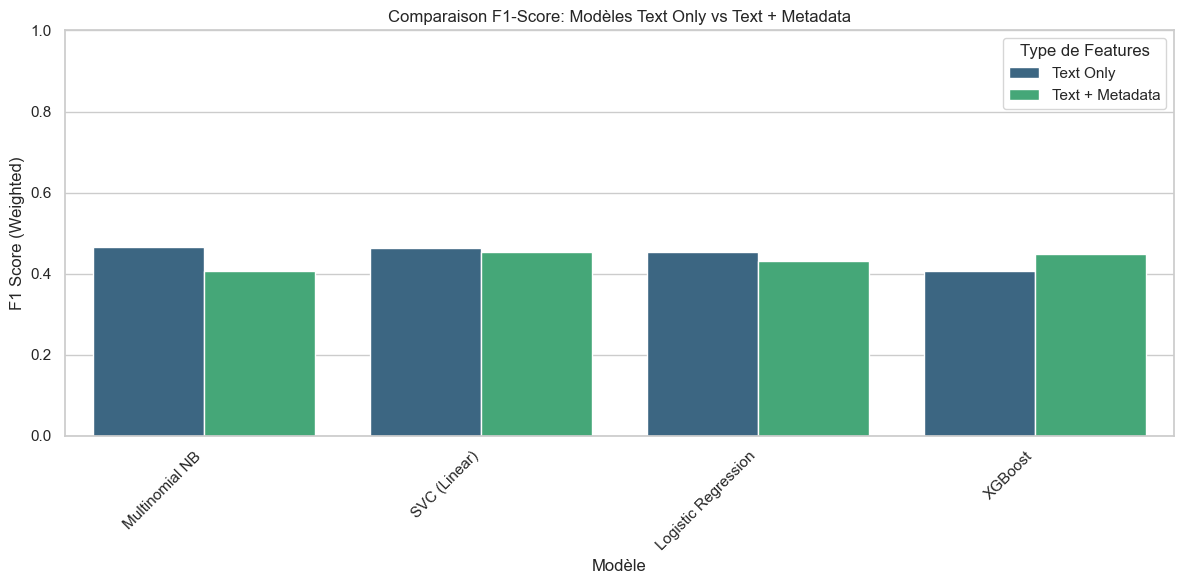

In [44]:

print("\n--- Comparaison Globale : Text Only vs Text + Metadata ---")
# Concaténer les DataFrames de résultats
all_results_df = pd.concat([
    results_df_text.assign(Type='Text Only'),
    results_df_full.assign(Type='Text + Metadata')
]).sort_values(by='F1 Weighted', ascending=False)

print(all_results_df)

plt.figure(figsize=(12, 6))
sns.barplot(data=all_results_df.reset_index(), x='index', y='F1 Weighted', hue='Type', palette='viridis')
plt.title('Comparaison F1-Score: Modèles Text Only vs Text + Metadata')
plt.xlabel('Modèle')
plt.ylabel('F1 Score (Weighted)')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Type de Features')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### les models les plus efficaces a utiliser semblent donc etre Mutinomial NB ou SVC (linear)

# ==============================================================================
# Phase 5 : Explicabilité du Modèle (SHAP)
# ==============================================================================

### Objectif : Comprendre pourquoi le meilleur modèle prend certaines décisions. Identifier les features (mots, n-grams, ou métadonnées) qui ont le plus d'influence sur la prédiction d'un sentiment positif, négatif ou neutre.
SHAP (SHapley Additive exPlanations) : Une technique populaire et théoriquement fondée pour l'explicabilité des modèles. Elle attribue à chaque feature une valeur (la "valeur SHAP") représentant sa contribution à l'écart entre la prédiction du modèle pour une instance donnée et la prédiction moyenne sur l'ensemble des données.
Sélection du Modèle : Le meilleur modèle global (basé sur le F1-score pondéré de la Phase 4) est sélectionné pour l'analyse.
- Préparation pour SHAP :
Les données de test (X_test) doivent être transformées en utilisant l'étape de prétraitement (TF-IDF ou ColumnTransformer) du pipeline sélectionné.
Les noms des features (mots du TF-IDF, catégories One-Hot des métadonnées) sont extraits pour pouvoir interpréter les résultats SHAP.
- Choix de l'Explainer SHAP :
- TreeExplainer : Efficace et exact pour les modèles basés sur des arbres (XGBoost, RandomForest, etc.).
LinearExplainer : Efficace pour les modèles linéaires (Logistic Regression, SVM linéaire).
- KernelExplainer : Fonctionne pour n'importe quel modèle (boîte noire) mais est beaucoup plus lent et approximatif. Il est utilisé en dernier recours et souvent sur un sous-ensemble de données. (Dans le code, il est désactivé par défaut pour éviter les longs temps de calcul).
- Calcul des Valeurs SHAP : L'explainer choisi est utilisé pour calculer les valeurs SHAP pour les données de test transformées. Pour la classification multi-classe, shap_values est généralement une liste de matrices, une pour chaque classe.
- Visualisations SHAP :
summary_plot : C'est la visualisation la plus courante. Elle montre les features les plus importantes globalement. Pour chaque feature, elle affiche la distribution des valeurs SHAP pour toutes les instances. La couleur indique souvent la valeur de la feature (haute/basse). Cela permet de voir quels mots/métadonnées poussent vers un sentiment spécifique. Par exemple, on s'attendrait à ce que le mot "happi" (stem de happy) ait des valeurs SHAP positives pour la classe "positive" et négatives pour la classe "négative". Si les métadonnées sont utilisées, on verra leur importance relative par rapport aux mots.
- force_plot (Optionnel) : Montre comment les différentes features contribuent à la prédiction pour une seule instance spécifique. Utile pour débugger ou comprendre un cas particulier.
- Limites : L'interprétation des SHAP values pour des milliers de features TF-IDF peut être complexe. Se concentrer sur le summary_plot et les features les plus importantes est souvent le plus pragmatique. La petite taille du dataset peut aussi rendre les valeurs SHAP moins stables.

In [45]:

# On choisit le meilleur modèle global pour l'explicabilité
# (ou un modèle bien performant et compatible avec SHAP comme XGBoost ou LogisticRegression)

best_overall_model_name = all_results_df.index[0]
best_overall_model_type = all_results_df.loc[best_overall_model_name, 'Type']
print(f"\nMeilleur modèle global identifié : {best_overall_model_name} ({best_overall_model_type})")

if best_overall_model_type == 'Text Only':
    best_pipeline = results_text_only[best_overall_model_name]['model']
    X_shap = X_test[text_feature]
    pipeline_preprocessing_step = best_pipeline.steps[0][1] # Le TF-IDF
    pipeline_model_step = best_pipeline.steps[1][1]
    # Transformer les données texte pour SHAP
    X_test_transformed = pipeline_preprocessing_step.transform(X_shap)
    feature_names_shap = pipeline_preprocessing_step.get_feature_names_out()

elif best_overall_model_type == 'Text + Metadata':
    best_pipeline = results_full[best_overall_model_name]['model']
    X_shap = X_test # Utiliser tout X_test
    pipeline_preprocessing_step = best_pipeline.steps[0][1] # Le ColumnTransformer
    pipeline_model_step = best_pipeline.steps[1][1]
    # Transformer toutes les données pour SHAP
    X_test_transformed = pipeline_preprocessing_step.fit_transform(X_train).toarray() # Fit sur train pour OHE
    X_test_transformed = pipeline_preprocessing_step.transform(X_shap).toarray() # Transform test, toarray pour dense
    # Obtenir les noms de features combinés (TF-IDF + OHE)
    feature_names_shap = list(pipeline_preprocessing_step.transformers_[0][1].get_feature_names_out()) + \
                         list(pipeline_preprocessing_step.transformers_[1][1].get_feature_names_out(metadata_features))
    # Convertir en DataFrame pour SHAP si nécessaire/plus simple pour certains explainers
    X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names_shap)

else:
    print("Type de modèle non reconnu pour SHAP.")
    best_pipeline = None


if SHAP_AVAILABLE and best_pipeline is not None:
    print(f"\n--- Explicabilité avec SHAP pour {best_overall_model_name} ---")

    try:
        # Choisir l'explainer SHAP approprié
        if isinstance(pipeline_model_step, (XGBClassifier)):
            print("Utilisation de TreeExplainer pour XGBoost.")
            explainer = shap.TreeExplainer(pipeline_model_step)
            # SHAP values pour les données transformées
            shap_values = explainer.shap_values(X_test_transformed)

        elif isinstance(pipeline_model_step, LogisticRegression) and pipeline_model_step.kernel == 'linear':
             print("Utilisation de LinearExplainer pour Logistic Regression.")
             # Masque pour éviter l'avertissement sur les features corrélées (approximation)
             explainer = shap.LinearExplainer(pipeline_model_step, X_test_transformed, feature_perturbation="interventional")
             shap_values = explainer.shap_values(X_test_transformed)

        elif isinstance(pipeline_model_step, SVC) and pipeline_model_step.kernel == 'linear':
             print("Utilisation de LinearExplainer pour SVC linéaire.")
             explainer = shap.LinearExplainer(pipeline_model_step, X_test_transformed, feature_perturbation="interventional")
             shap_values = explainer.shap_values(X_test_transformed)

        else:
            # Fallback sur KernelExplainer (plus lent, approximatif)
            # Attention: Peut être très lent sur beaucoup de features/données
            print(f"Utilisation de KernelExplainer (peut être lent) pour {type(pipeline_model_step)}.")
            # Prendre un petit échantillon pour l'explication pour accélérer
            # K = 100 # Nombre de points pour le background
            # X_train_summary = shap.kmeans(pipeline_preprocessing_step.transform(X_train[:500]), K) # Utiliser la transformation appropriée
            # explainer = shap.KernelExplainer(pipeline_model_step.predict_proba, X_train_summary)
            # shap_values = explainer.shap_values(X_test_transformed[:50], nsamples=100) # Expliquer seulement 50 points test
            print("KernelExplainer désactivé par défaut pour la performance. Décommentez si nécessaire et ajustez.")
            shap_values = None # Désactivé

        if shap_values is not None:
             # Affichage du Summary Plot (Importance globale des features)
             # Pour multi-classe, shap_values est une liste [classe0, classe1, classe2]
             print("\nSHAP Summary Plot (Importance des features par classe)")
             shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names_shap,
                               class_names=['neutral', 'positive', 'negative'], max_display=20) # Affiche top 20 features

             # (Optionnel) Force plot pour une prédiction individuelle
             # index_to_explain = 0 # Expliquer la première instance du jeu de test
             # print(f"\nAnalyse d'une prédiction individuelle (Instance {index_to_explain})")
             # print(f"Texte original: {X_test.iloc[index_to_explain]['text']}")
             # if best_overall_model_type == 'Text + Metadata':
             #      print(f"Métadonnées: Platform={X_test.iloc[index_to_explain]['Platform']}, Time={X_test.iloc[index_to_explain]['Time of Tweet']}")
             # print(f"Vrai Sentiment: {y_test.iloc[index_to_explain]}")
             # print(f"Prédiction Modèle: {best_pipeline.predict(X_shap)[index_to_explain]}")
             # shap.force_plot(explainer.expected_value[1], shap_values[1][index_to_explain,:], X_test_transformed.iloc[index_to_explain,:], feature_names=feature_names_shap, matplotlib=True) # Pour la classe positive (classe 1)
             # plt.show()

    except Exception as e:
        print(f"Erreur lors de la génération des explications SHAP : {e}")
        print("L'explicabilité n'a pas pu être réalisée pour ce modèle/ces données.")

else:
    print("\nExplicabilité SHAP non disponible ou non exécutée.")


Meilleur modèle global identifié : Multinomial NB (Multinomial NB          Text Only
Multinomial NB    Text + Metadata
Name: Type, dtype: object)


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

# ==============================================================================
# Phase 6 : Sélection Finale et Fonctions de Production
# ==============================================================================

### Objectif : Sélectionner les modèles finaux basés sur les évaluations, créer des fonctions robustes pour ré-entraîner ces modèles et les sauvegarder, et développer une fonction de prédiction simple et flexible utilisable potentiellement dans une application.
- Sélection Finale : Les meilleurs modèles de chaque catégorie ("Text Only" et "Text + Metadata") sont identifiés d'après les F1-scores obtenus précédemment. On décide quels modèles on veut "mettre en production" (ici, on garde les deux meilleurs pour la flexibilité). Les chemins de sauvegarde sont définis.
- Fonction train_and_save_final_model :
Prend en entrée un pipeline Sklearn configuré (contenant le préprocesseur et le classifieur choisi), les données X et y, et un chemin de sauvegarde.
Ré-entraîne le pipeline sur l'ensemble des données fournies (ici, tout le dataset X, y). C'est une pratique courante pour le modèle final, afin qu'il bénéficie de toute l'information disponible. Alternative : entraîner uniquement sur X_train, y_train si l'on veut garder X_test, y_test pour une validation ultérieure totalement indépendante.
Sauvegarde le pipeline complet (incluant le vectorizer/encoder ET le modèle entraîné) dans un fichier .joblib. Sauvegarder le pipeline est crucial car cela garantit que les mêmes étapes de prétraitement seront appliquées lors de la prédiction.
- Fonction predict_sentiment :
C'est la fonction clé pour l'utilisation du modèle. Elle est conçue pour être flexible.
Prend en entrée les données à prédire (input_data), le chemin vers le modèle sauvegardé (model_path), et un booléen use_metadata pour savoir quel type de modèle charger et comment traiter l'entrée.
Charge le pipeline .joblib.
- Prépare les données d'entrée : une liste avec une chaîne pour "Text Only", ou un DataFrame d'une ligne pour "Text + - Metadata". Note importante : Si le modèle avec métadonnées a été entraîné sur cleaned_text, il faut s'assurer que le texte dans input_data est aussi prétraité avant d'être passé au pipeline (fait dans l'exemple d'utilisation).
Appelle pipeline.predict() pour obtenir la prédiction encodée (0, 1, ou 2).
Appelle pipeline.predict_proba() (si disponible) pour obtenir les probabilités associées à chaque classe.
Utilise final_output_map pour convertir la prédiction encodée (0, 1, 2) vers le format de sortie demandé : un dictionnaire avec label ('neutral', 'positive', 'negative') et value (0, 1, -1).
Retourne le dictionnaire de résultat et la probabilité de la classe prédite.
Inclut une gestion des erreurs (fichier non trouvé, erreurs de prédiction).
- Exemples d'Utilisation : Montrent comment appeler predict_sentiment pour les deux types de modèles (Text Only et Text + Metadata) avec des exemples de textes/données.

### 6.1 Sélection Finale des Modèles

In [46]:
print("\n" + "="*50)
print(" Phase 6 : Sélection Finale et Fonctions de Production ")
print("="*50 + "\n")


# Basée sur les performances (F1-Weighted) et potentiellement l'analyse des learning curves/explicabilité

# Meilleur modèle Text Only
best_text_model_name = results_df_text.index[0]
best_text_pipeline = results_text_only[best_text_model_name]['model']
print(f"Meilleur modèle 'Text Only' sélectionné : {best_text_model_name} (F1: {results_df_text.loc[best_text_model_name, 'F1 Weighted']:.4f})")

# Meilleur modèle Text + Metadata (s'il a été entraîné)
if results_full:
    best_full_model_name = results_df_full.index[0]
    best_full_pipeline = results_full[best_full_model_name]['model']
    print(f"Meilleur modèle 'Text + Metadata' sélectionné : {best_full_model_name} (F1: {results_df_full.loc[best_full_model_name, 'F1 Weighted']:.4f})")
else:
    best_full_model_name = None
    best_full_pipeline = None
    print("Aucun modèle 'Text + Metadata' n'a été entraîné ou évalué.")

# Choix du modèle final à déployer (on pourrait choisir le meilleur des deux, ou garder les deux options)
# Ici, on garde les deux meilleurs de chaque catégorie pour la flexibilité
final_model_text_path = 'sentiment_model_text_only.joblib'
final_model_full_path = 'sentiment_model_text_metadata.joblib'



 Phase 6 : Sélection Finale et Fonctions de Production 

Meilleur modèle 'Text Only' sélectionné : Multinomial NB (F1: 0.4666)
Meilleur modèle 'Text + Metadata' sélectionné : SVC (Linear) (F1: 0.4541)


### 6.2 Fonction pour Entraîner et Sauvegarder le Modèle Final

In [48]:
# Cette fonction ré-entraîne le pipeline choisi sur l'ENSEMBLE des données (train + test)
# ou juste sur le train set si on préfère garder le test set pour une ultime validation jamais vue.
# Option: Entraîner sur tout le dataset (X, y) pour utiliser toute l'information disponible.

def train_and_save_final_model(pipeline_config, data_X, data_y, save_path, model_description=""):
    """
    Entraîne un pipeline sur les données fournies et le sauvegarde.

    Args:
        pipeline_config (Pipeline): Le pipeline Sklearn configuré (avec le bon modèle).
        data_X (pd.DataFrame or pd.Series): Les features (texte ou texte+métadata).
        data_y (pd.Series): La cible.
        save_path (str): Chemin où sauvegarder le fichier .joblib.
        model_description (str): Description du modèle pour l'affichage.
    """
    print(f"\nEntraînement final du modèle : {model_description}")
    print(f"Utilisation de {data_X.shape[0]} exemples.")

    try:
        # Entraînement sur toutes les données fournies
        pipeline_config.fit(data_X, data_y)
        print("Entraînement terminé.")

        # Sauvegarde du pipeline complet (préprocesseur + modèle)
        joblib.dump(pipeline_config, save_path)
        print(f"Pipeline sauvegardé avec succès dans : {save_path}")
        return True

    except Exception as e:
        print(f"Erreur lors de l'entraînement ou de la sauvegarde du modèle {model_description} : {e}")
        return False

# Ré-entraîner et sauvegarder les modèles sélectionnés sur l'ensemble des données
print("\n--- Préparation des modèles finaux ---")

# Modèle Text Only
train_and_save_final_model(best_text_pipeline, X[text_feature], y, final_model_text_path,
                           model_description=f"{best_text_model_name} (Text Only)")

# Modèle Text + Metadata (si pertinent)
if best_full_pipeline:
    train_and_save_final_model(best_full_pipeline, X, y, final_model_full_path,
                               model_description=f"{best_full_model_name} (Text + Metadata)")




--- Préparation des modèles finaux ---

Entraînement final du modèle : Multinomial NB (Text Only)
Utilisation de 394 exemples.
Entraînement terminé.
Pipeline sauvegardé avec succès dans : sentiment_model_text_only.joblib

Entraînement final du modèle : SVC (Linear) (Text + Metadata)
Utilisation de 394 exemples.
Entraînement terminé.
Pipeline sauvegardé avec succès dans : sentiment_model_text_metadata.joblib


### 6.3 Fonction de Prédiction Flexible

In [49]:

# Charge le modèle sauvegardé et fait une prédiction

# Mapping inverse pour obtenir le nom du sentiment
sentiment_map_inverse = {v: k for k, v in sentiment_map.items()}
# Mapping final vers -1, 0, 1 comme demandé
final_output_map = {
    0: {'label': 'neutral', 'value': 0},  # neutral (0) -> 0
    1: {'label': 'positive', 'value': 1}, # positive (1) -> 1
    2: {'label': 'negative', 'value': -1} # negative (2) -> -1
}


def predict_sentiment(input_data, model_path='sentiment_model_text_only.joblib', use_metadata=False):
    """
    Charge un modèle de sentiment sauvegardé et prédit le sentiment pour une entrée.

    Args:
        input_data (str or dict or pd.Series):
            - Si use_metadata=False: Une chaîne de caractères (le texte).
            - Si use_metadata=True: Un dictionnaire ou pd.Series contenant
              la clé du texte (ex: 'cleaned_text') et les clés des métadonnées
              (ex: 'Platform', 'Time of Tweet').
        model_path (str): Chemin vers le fichier .joblib du modèle sauvegardé.
        use_metadata (bool): Indique si le modèle à charger utilise les métadonnées.

    Returns:
        dict: Un dictionnaire contenant 'label' (nom du sentiment) et 'value' (-1, 0, ou 1),
              ou None en cas d'erreur.
        float: La probabilité associée à la classe prédite (si le modèle le permet).
               Retourne None si non disponible ou en cas d'erreur.
    """
    try:
        # Charger le pipeline sauvegardé
        pipeline = joblib.load(model_path)
        print(f"Modèle chargé depuis : {model_path}")

        # Préparer les données d'entrée pour la prédiction
        if use_metadata:
            if not isinstance(input_data, (dict, pd.Series)):
                raise ValueError("Pour use_metadata=True, input_data doit être un dict ou pd.Series.")
            # Convertir en DataFrame avec une seule ligne
            input_df = pd.DataFrame([input_data])
            # S'assurer que la colonne texte est bien nommée (si prétraitement externe)
            # Ici on assume que le pipeline gère le 'cleaned_text' à partir de 'text' si nécessaire,
            # mais il est plus sûr que l'input_data ait déjà la colonne 'cleaned_text' si le pipeline
            # a été entraîné dessus directement (comme dans notre cas pour le ColumnTransformer).
            # Il faut s'assurer que l'input_df a les colonnes attendues par le ColumnTransformer
            # ('cleaned_text', 'Platform', 'Time of Tweet')
            # Exemple: Pré-nettoyer le texte avant de passer le dict:
            # if 'text' in input_data and 'cleaned_text' not in input_data:
            #    input_data['cleaned_text'] = preprocess_text_stemming(input_data['text'])
            data_to_predict = input_df

        else: # Text Only
            if not isinstance(input_data, str):
                raise ValueError("Pour use_metadata=False, input_data doit être une chaîne de caractères.")
            # Le pipeline TF-IDF attend une liste/série de textes
            data_to_predict = [input_data] # Mettre la chaîne dans une liste

        # Faire la prédiction
        prediction_encoded = pipeline.predict(data_to_predict)[0]

        # Obtenir les probabilités (si possible)
        probabilities = None
        if hasattr(pipeline, "predict_proba"):
            try:
                proba = pipeline.predict_proba(data_to_predict)[0]
                probabilities = proba
                predicted_probability = proba[prediction_encoded]
                print(f"Probabilités prédites : {proba}")
                print(f"Probabilité pour la classe prédite ({prediction_encoded}): {predicted_probability:.4f}")
            except Exception as proba_e:
                 print(f"Impossible d'obtenir les probabilités : {proba_e}")
                 predicted_probability = None
        else:
            predicted_probability = None


        # Mapper le résultat encodé vers le format final (-1, 0, 1 et label)
        result = final_output_map.get(prediction_encoded)

        if result:
            print(f"Prédiction Encodée: {prediction_encoded} -> Label: {result['label']}, Valeur: {result['value']}")
            return result, predicted_probability
        else:
            print(f"Erreur : Code de prédiction inconnu ({prediction_encoded})")
            return None, None

    except FileNotFoundError:
        print(f"Erreur : Fichier modèle non trouvé à {model_path}")
        return None, None
    except Exception as e:
        print(f"Erreur lors de la prédiction : {e}")
        return None, None



### 6.4 Exemples d'utilisation de la fonction de prédiction

In [50]:
print("\n--- Test de la fonction de prédiction ---")

# Exemple 1: Text Only
text_to_predict = "This is such a wonderful and amazing experience, I love it!"
print(f"\nPrédiction pour (Text Only): '{text_to_predict}'")
result_text, proba_text = predict_sentiment(text_to_predict, model_path=final_model_text_path, use_metadata=False)
if result_text:
    print(f"Sentiment prédit (Text Only): {result_text}")

text_to_predict_neg = "I am feeling very sad and angry today."
print(f"\nPrédiction pour (Text Only): '{text_to_predict_neg}'")
result_text_neg, proba_text_neg = predict_sentiment(text_to_predict_neg, model_path=final_model_text_path, use_metadata=False)
if result_text_neg:
    print(f"Sentiment prédit (Text Only): {result_text_neg}")


# Exemple 2: Text + Metadata (si le modèle existe)
if best_full_pipeline:
    metadata_input = {
        'cleaned_text': preprocess_text_stemming("Just watching a movie on Facebook tonight."), # Important: Prétraiter le texte!
        'Platform': 'Facebook',
        'Time of Tweet': 'night'
        # Assurez-vous que les valeurs de Platform/Time sont valides (vues dans le train set)
    }
    print(f"\nPrédiction pour (Text + Metadata): {metadata_input}")
    result_full, proba_full = predict_sentiment(metadata_input, model_path=final_model_full_path, use_metadata=True)
    if result_full:
        print(f"Sentiment prédit (Text + Metadata): {result_full}")

    metadata_input_pos = {
        'cleaned_text': preprocess_text_stemming("Great meeting this morning on Twitter!"),
        'Platform': 'Twitter',
        'Time of Tweet': 'morning'
    }
    print(f"\nPrédiction pour (Text + Metadata): {metadata_input_pos}")
    result_full_pos, proba_full_pos = predict_sentiment(metadata_input_pos, model_path=final_model_full_path, use_metadata=True)
    if result_full_pos:
        print(f"Sentiment prédit (Text + Metadata): {result_full_pos}")


--- Test de la fonction de prédiction ---

Prédiction pour (Text Only): 'This is such a wonderful and amazing experience, I love it!'
Modèle chargé depuis : sentiment_model_text_only.joblib
Probabilités prédites : [0.27762827 0.62447583 0.0978959 ]
Probabilité pour la classe prédite (1): 0.6245
Prédiction Encodée: 1 -> Label: positive, Valeur: 1
Sentiment prédit (Text Only): {'label': 'positive', 'value': 1}

Prédiction pour (Text Only): 'I am feeling very sad and angry today.'
Modèle chargé depuis : sentiment_model_text_only.joblib
Probabilités prédites : [0.51749935 0.22456345 0.2579372 ]
Probabilité pour la classe prédite (0): 0.5175
Prédiction Encodée: 0 -> Label: neutral, Valeur: 0
Sentiment prédit (Text Only): {'label': 'neutral', 'value': 0}

Prédiction pour (Text + Metadata): {'cleaned_text': 'watch movi facebook tonight', 'Platform': 'Facebook', 'Time of Tweet': 'night'}
Modèle chargé depuis : sentiment_model_text_metadata.joblib
Probabilités prédites : [0.14042545 0.78174465